# Dataset Distributions

This notebook investigates the distributions of key political identity-building categories related to political actors, based on dataset metadata - with a focus on sentiment-related trends of membership and group relation categories.  

### Categories of Interest
- **Membership**: Political parties, parliamentary groups, ministers  
- *Ideology*: Party families, GAL–TAN positionings (CHES variables)  
- **Group Relations**: Party status (Coalition vs. Opposition), political orientation (LREGEN, LRECON, Wikipedia classifications)  

### Purpose

The goal of this exploration is to:
1. *Investigate basic distributions* to gain an overview of the dataset’s structure  
2. *Identify trends* within the political landscape of the studied parliamentary period  

### Focus Areas
- *Party activity*: How political parties and groups are distributed and represented  
- *Sentiment trends*: Patterns in sentiment across different ideological or group categories  

--- 

Sample input: 
Pre-processed dataset [ParlaMint-SI_5.1_master.tsv](../Sample/Datasets/ParlaMint-SI_5.1_master.tsv) 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [2]:
df = pd.read_csv("../Sample/Datasets/Sample_master.tsv", sep="\t", encoding="utf-8")
df.head()

,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Sents,Words,Tokens,Parties,Year,Parlamint,lrgen,galtan,Family,Seat
0,ParlaMint-SI_2019-11-22-SDZ8-Redna-13.u1,"Spoštovane poslanke, spoštovani poslanci, gosp...",2019-11-22,Term 8,Redna,Reference,Chairperson,MP,notMinister,SD,...,26,548,640,ZLSD/SD,2019,SD,2.6,2.5,Socialist,11.4
1,ParlaMint-SI_2019-11-22-SDZ8-Redna-13.u2,"Spoštovani predsednik Državnega zbora, hvala z...",2019-11-22,Term 8,Redna,Reference,Regular,notMP,notMinister,-,...,25,585,646,-,2019,NaN,NaN,NaN,NaN,NaN
2,ParlaMint-SI_2019-11-22-SDZ8-Redna-13.u3,"Hvala, gospa direktorica, za dopolnilno obrazl...",2019-11-22,Term 8,Redna,Reference,Chairperson,MP,notMinister,SD,...,3,25,31,ZLSD/SD,2019,SD,2.6,2.5,Socialist,11.4
3,ParlaMint-SI_2019-11-22-SDZ8-Redna-13.u4,"Spoštovani predsedujoči, kolegice in kolegi! O...",2019-11-22,Term 8,Redna,Reference,Regular,MP,notMinister,LMŠ,...,18,431,467,LMŠ,2019,LMŠ,4.4,4.6,Liberal,14.8
4,ParlaMint-SI_2019-11-22-SDZ8-Redna-13.u5,"Hvala, gospod predsednik, za predstavitev stal...",2019-11-22,Term 8,Redna,Reference,Chairperson,MP,notMinister,SD,...,4,33,44,ZLSD/SD,2019,SD,2.6,2.5,Socialist,11.4


## Dataset characteristics

In [3]:
print(df.shape)
df.describe(include="all")

(5404, 31)


,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Sents,Words,Tokens,Parties,Year,Parlamint,lrgen,galtan,Family,Seat
count,5404,5404,5404,5404,5404,5404,5404,5404,5404,5404,...,5404.000000,5404.000000,5404.000000,5404,5404.000000,2529,2529.000000,2529.000000,2529,2529.000000
unique,5404,5047,27,1,2,2,2,2,2,11,...,NaN,NaN,NaN,11,NaN,9,NaN,NaN,6,NaN
top,ParlaMint-SI_2019-11-22-SDZ8-Redna-13.u1,"Hvala lepa. Gospod minister, izvolite.",2019-11-18,Term 8,Redna,Reference,Chairperson,MP,notMinister,SDS,...,NaN,NaN,NaN,SDS,NaN,SDS,NaN,NaN,Socialist,NaN
freq,1,54,413,5404,4020,3546,2730,4908,5032,1060,...,NaN,NaN,NaN,1060,NaN,605,NaN,NaN,761,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.352147,263.004256,307.723353,NaN,2019.484086,NaN,4.844524,5.068288,NaN,14.554132
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.176487,418.059590,491.393875,NaN,0.499793,NaN,2.627069,2.622796,NaN,8.313119
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,2.000000,NaN,2019.000000,NaN,0.700000,1.000000,NaN,4.500000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,13.000000,17.000000,NaN,2019.000000,NaN,2.600000,2.500000,NaN,8.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.000000,78.500000,94.000000,NaN,2019.000000,NaN,4.400000,4.600000,NaN,11.400000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.000000,390.000000,452.000000,NaN,2020.000000,NaN,8.600000,8.500000,NaN,14.800000


In [4]:
reg_speeches = df[df["Speaker_role"] == "Regular"]
party = df["Speaker_party"].unique()

print("No. of all speeches: ", len(df))
print("Speeches of regular speakers: ", len(reg_speeches), "%: ", (len(reg_speeches)/len(df))*100)
print("Earliest date: ", df["Date"].min())
print("Latest date: ", df["Date"].max())
print("No. of unique parties ", len(party), party)
print("Sentiment 6-class: ", df["Senti_6"].value_counts())
print("Sentiment 3-class: ", df["Senti_3"].value_counts()
)

reg_6 = reg_speeches["Senti_6"].value_counts()
reg_3 = reg_speeches["Senti_3"].value_counts()
percent_reg6 = (reg_6 / len(reg_speeches)) * 100
percent_reg3 = (reg_3 / len(reg_speeches)) * 100
print ("Distribution of the 6-class sent in procedural speeches: ", percent_reg6)
print("Distribution of the 3-class sent in procedural speeches: ", percent_reg3)


No. of all speeches:  5404
Speeches of regular speakers:  2674 %:  49.48186528497409
Earliest date:  2019-11-18
Latest date:  2020-04-30
No. of unique parties  11 ['SD' '-' 'LMŠ' 'SAB' 'DeSUS' 'SNS' 'SDS' 'SMC' 'NSi' 'Levica' 'IMNS']
Sentiment 6-class:  Senti_6
neutral positive    2804
negative            1164
neutral negative     543
mixed negative       537
mixed positive       274
positive              82
Name: count, dtype: int64
Sentiment 3-class:  Senti_3
Neutral     3347
Negative    1701
Positive     356
Name: count, dtype: int64
Distribution of the 6-class sent in procedural speeches:  Senti_6
negative            42.819746
mixed negative      18.623785
neutral negative    13.799551
neutral positive    11.854899
mixed positive       9.910247
positive             2.991773
Name: count, dtype: float64
Distribution of the 3-class sent in procedural speeches:  Senti_3
Negative    61.443530
Neutral     25.654450
Positive    12.902019
Name: count, dtype: float64


In [5]:
#Sentiment in procedural speeches
chair = df[df["Speaker_role"] != "Regular"]
print("Sentiment 6-class: ", chair["Senti_6"].value_counts())
print("Sentiment 3-class: ", chair["Senti_3"].value_counts()
)

chair_6 = chair["Senti_6"].value_counts()
chair_3 = chair["Senti_3"].value_counts()

percent_chair6 = (chair_6 / len(chair)) * 100
percent_chair3 = (chair_3 / len(chair)) * 100

print ("Distribution of the 6-class sent in procedural speeches: ", percent_chair6)
print("Distribution of the 3-class sent in procedural speeches: ", percent_chair3)

Sentiment 6-class:  Senti_6
neutral positive    2487
neutral negative     174
mixed negative        39
negative              19
mixed positive         9
positive               2
Name: count, dtype: int64
Sentiment 3-class:  Senti_3
Neutral     2661
Negative      58
Positive      11
Name: count, dtype: int64
Distribution of the 6-class sent in procedural speeches:  Senti_6
neutral positive    91.098901
neutral negative     6.373626
mixed negative       1.428571
negative             0.695971
mixed positive       0.329670
positive             0.073260
Name: count, dtype: float64
Distribution of the 3-class sent in procedural speeches:  Senti_3
Neutral     97.472527
Negative     2.124542
Positive     0.402930
Name: count, dtype: float64


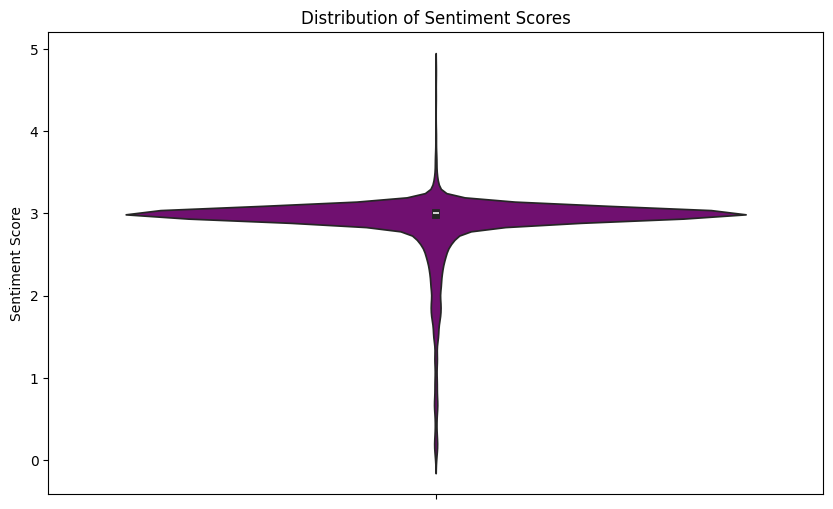

In [6]:
#Sentiment scores distribution
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=chair,
    y="Senti_n", 
    color="purple",
)
plt.title("Distribution of Sentiment Scores")
plt.ylabel("Sentiment Score")
plt.show()

Observations (sample run): 

Entire dataset:
- No. of all speeches:  5404
- Speeches of regular speakers:  2674 %:  49.48186528497409
- Sentiment 3-class:  Senti_3
    - Negative    61.443530
    - Neutral     25.654450
    - Positive    12.902019

Chairperson speeches only: 
Distribution of the 3-class sent in procedural speeches:  Senti_3:
    - Neutral     97.472527
    - Negative     2.124542
    - Positive     0.402930


- The dataset consists of over 50% of chairperson speeches, which heavily dominates in the Neutral sentiment, which can directly impact the analysis results. Therefore, for the majority of the analysis, these speeches should be removed.

In [7]:
# Removing procedural speeches for the analysis, rechecking base characteristics
df = df[df["Speaker_role"] == "Regular"]

print("No. of all speeches: ", len(df))
print("Earliest date: ", df["Date"].min())
print("Latest date: ", df["Date"].max())
print("No. of unique parties ", len(party), party)
print("Sentiment 6-class: ", df["Senti_6"].value_counts())
print("Sentiment 3-class: ", df["Senti_3"].value_counts())


No. of all speeches:  2674
Earliest date:  2019-11-18
Latest date:  2020-04-30
No. of unique parties  11 ['SD' '-' 'LMŠ' 'SAB' 'DeSUS' 'SNS' 'SDS' 'SMC' 'NSi' 'Levica' 'IMNS']
Sentiment 6-class:  Senti_6
negative            1145
mixed negative       498
neutral negative     369
neutral positive     317
mixed positive       265
positive              80
Name: count, dtype: int64
Sentiment 3-class:  Senti_3
Negative    1643
Neutral      686
Positive     345
Name: count, dtype: int64


## Party-level Overview
Inspecting speech and sentiment distributions across party-, status- and political orientation.

In [8]:
# Table with overview of speeches, sentiment avg and sent percentages
#mapping = {"Far right":"FR", 
# "Right to far right": "R-FR", 
# "Centre-right":"CR", 
# "Centre to centre-left":"C-CR", 
# "Centre":"C", 
# "Centre to centre-left":"C-CL", 
# "Centre-left":"CL", 
# "Left":"L", 
# "Left to far left": "L-FL", 
# "Far left": "FL", 
# "-":"-", }

status = df.groupby(['Parties','Party_status']).size().unstack(fill_value=0)
status.columns = ['Speech (U)', 'Speech (C)', 'Speech (O)']
avg_sent = df.groupby(['Parties', 'Party_status'])["Senti_n"].mean().unstack(fill_value=0)
avg_sent.columns = ['Avg. Sent (U)', 'Avg. Sent (C)', 'Avg. Sent (O)']
sent_count = df.groupby(['Parties', df['Senti_3']]).size().unstack(fill_value=0)
sent_percent = sent_count.div(sent_count.sum(axis=1), axis=0) * 100

party_metadata = df[['Parties', 'Party_orientation']].drop_duplicates().set_index('Parties')


overview = (
    status.merge(avg_sent, on="Parties", how="left")
    .merge(sent_percent, on="Parties", how="left")
    .merge(party_metadata, on="Parties", how='left')
    .reset_index()
    )

overview.rename(columns={
    'Positive': '% Positive',
    'Neutral': '% Neutral',
    'Negative': '% Negative'
}, inplace=True)


overview['Total Speeches'] = overview['Speech (U)'] + overview['Speech (C)'] + overview['Speech (O)']
total_speeches = overview['Total Speeches'].sum()
overview['Speech %'] = (overview['Total Speeches'] / total_speeches) * 100
overview = overview[['Parties', 'Party_orientation', 'Total Speeches', 'Speech %', 'Speech (C)', 'Speech (O)','Speech (U)',
               'Avg. Sent (C)', 'Avg. Sent (O)','Avg. Sent (U)', '% Positive', '% Neutral', '% Negative']]

cols_to_format = [
    'Speech %', 'Avg. Sent (C)', 'Avg. Sent (O)', 'Avg. Sent (U)',
    '% Positive', '% Neutral', '% Negative'
]

for col in cols_to_format:
    overview[col] = overview[col].map(lambda x: f"{x:.1f}")

overview

,Parties,Party_orientation,Total Speeches,Speech %,Speech (C),Speech (O),Speech (U),Avg. Sent (C),Avg. Sent (O),Avg. Sent (U),% Positive,% Neutral,% Negative
0,-,-,496,18.5,0,0,496,0.0,0.0,2.1,12.9,52.0,35.1
1,DeSUS,Centre to centre-left,134,5.0,134,0,0,2.0,0.0,0.0,23.1,33.6,43.3
2,IMNS,-,11,0.4,0,0,11,0.0,0.0,4.2,90.9,9.1,0.0
3,LMŠ,Centre to centre-left,198,7.4,127,71,0,1.9,1.3,0.0,18.2,26.8,55.1
4,NSi,Centre-right,183,6.8,31,152,0,2.9,1.3,0.0,18.0,22.4,59.6
5,SDS,Right,467,17.5,50,417,0,2.7,0.9,0.0,9.9,16.7,73.4
6,SMC/GAS/Konkretno,Centre to centre-left,203,7.6,203,0,0,1.5,0.0,0.0,15.3,25.1,59.6
7,SNS,Right to far-right,140,5.2,0,140,0,0.0,0.9,0.0,5.0,17.9,77.1
8,ZL/Levica,Left,470,17.6,0,470,0,0.0,0.6,0.0,2.6,10.4,87.0
9,ZLSD/SD,Centre-left,208,7.8,137,71,0,1.9,1.0,0.0,20.2,19.7,60.1


## Party Activity
Investigation of party presence throughout the period, covered by the dataset. There are also several exceptions that need to be handled: 
- NeP = parliamentary group of independent MPs, which could be considered for the analysis, however, since there is no destinction between different NePs in different mandates, this is not included in the visualisation.
- NP = individual independent MPs, not connected into a parliamentary group. In addition to them not being a formal parliamentary entity but individual speakers, they have similar problem as NeP, ruled out
- Lipa and Konkretno = both are non-parliamentary parties. Specfically, both parties were consistuted within Parliament after being elected as a different parliamentary party. Included in the analysis

In [9]:
df["Month"] = df["Date"].str.split("-").str[:2].str.join("-")

activity = df.groupby(['Parties', 'Month']).agg(
    Start_date=('Date', 'min'),
    End_date=('Date', 'max'),
    Speech_count=('Date', 'size'),
    Avg_sentiment=('Senti_n','mean')

).reset_index()
activity = activity[~activity['Parties'].isin(["-", "NeP", "NP"])]
activity


activity

,Parties,Month,Start_date,End_date,Speech_count,Avg_sentiment
5,DeSUS,2019-11,2019-11-18,2019-11-29,43,1.917674
6,DeSUS,2019-12,2019-12-02,2019-12-20,30,1.870333
7,DeSUS,2020-01,2020-01-27,2020-01-29,15,1.363333
8,DeSUS,2020-03,2020-03-03,2020-03-19,24,2.144167
9,DeSUS,2020-04,2020-04-02,2020-04-30,22,2.562727
10,IMNS,2019-11,2019-11-19,2019-11-26,2,4.400000
11,IMNS,2019-12,2019-12-02,2019-12-02,1,4.070000
12,IMNS,2020-01,2020-01-28,2020-01-28,1,4.370000
13,IMNS,2020-03,2020-03-03,2020-03-13,5,4.122000
14,IMNS,2020-04,2020-04-02,2020-04-28,2,4.390000


In [10]:
import plotly.express as px
from PIL import Image

def plot_party_activity(df, mode="timeline"):
    if mode=="scatter":  ## Use for sample visualisation, for full dataset, use timeline
        fig = px.scatter(
            activity, 
            x="Start_date", 
            y="Parties", #Can be either Speaker_party for full range of individual parties, or Grouped_parties to emphasise changes in the lifespan of parties 
            size="Speech_count", 
            color="Parties", 
            hover_name="Parties", 
            title="Party activity", 
            labels={"Speech_count": "Speech Count"},
        )
    elif mode=="timeline":
        fig = px.timeline(
            activity,
            x_start="Start_date",
            x_end="End_date",
            y="Parties",
            color="Speech_count",
            title="Party Activity Across Terms (Gantt Chart)",
            labels={"Speech_count": "Party Activity"},
        )
    else:
        raise ValueError("mode must be one of: scatter, bar, heatmap, timeline")
    fig.update_layout(
        height=500,  
        width=950,
        yaxis_title="Party",
        xaxis_title="")
    return fig

#fig.write_image("path.png")


fig = plot_party_activity(activity, mode="timeline")
fig.show()

## Sentiment trends (across party, political orientations, statuses...)

In [11]:
sent_mapping = {
    "negative":"Negative", 
    "neutral negative":"Neutral Negative", 
    "neutral positive":"Neutral Positive", 
    "mixed negative":"Mixed Negative", 
    "mixed positive":"Mixed Positive", 
    "positive":"Positive",
}

df['Senti_6'] = df["Senti_6"].map(sent_mapping).fillna(df["Senti_6"])
df["Senti_6"].unique()

array(['Mixed Positive', 'Positive', 'Neutral Negative', 'Mixed Negative',
       'Neutral Positive', 'Negative'], dtype=object)

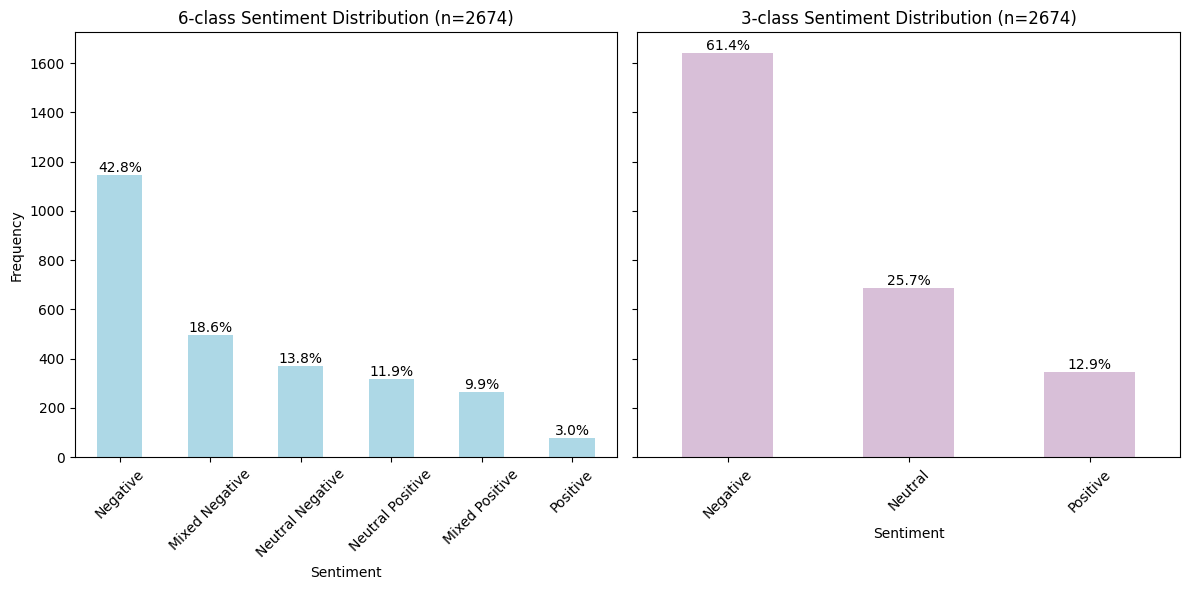

In [12]:
#General sentiment distribution in the corpus
df_sent6 = df["Senti_6"].value_counts()
df_sent3 = df["Senti_3"].value_counts()

def add_percentage(ax, counts):
    total = counts.sum()
    for p in ax.patches:
        percentage = f"{(p.get_height() / total) * 100:.1f}%"
        ax.annotate(percentage,  (p.get_x() + p.get_width() / 2, p.get_height()), 
                    ha='center', va='bottom', fontsize=10, color='black')

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
df_sent6.plot(kind='bar', ax=axes[0], color = 'lightblue')
axes[0].set_title(f'6-class Sentiment Distribution (n={len(df)})')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)
add_percentage(axes[0], df_sent6)

df_sent3.plot(kind='bar', ax=axes[1], color='thistle')
axes[1].set_title(f'3-class Sentiment Distribution (n={len(df)})')
axes[1].set_xlabel('Sentiment')
axes[1].tick_params(axis='x', rotation=45)
add_percentage(axes[1], df_sent3)

plt.tight_layout()
plt.show()

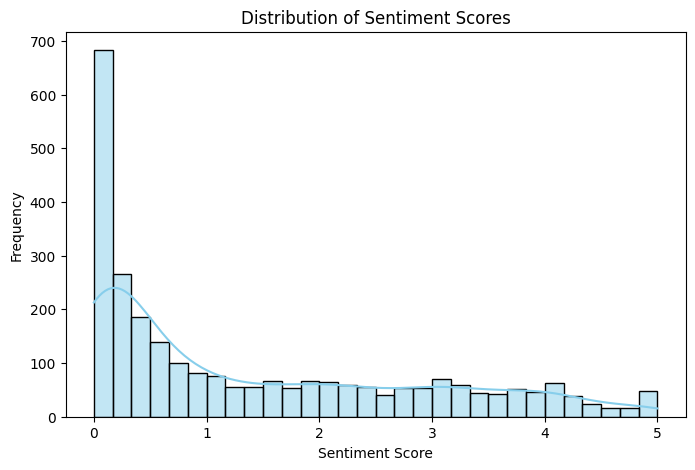

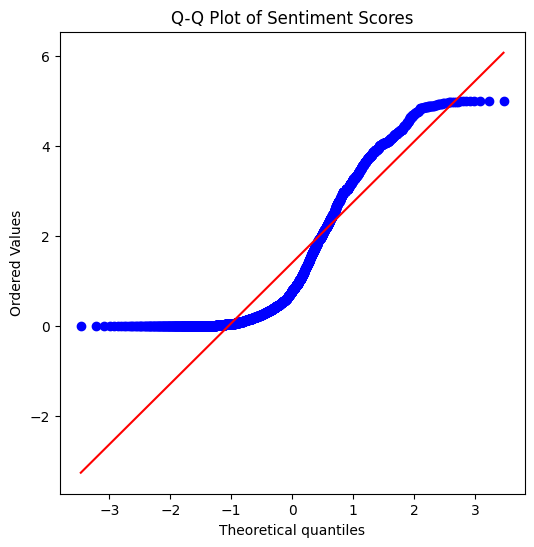

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Senti_n"], bins=30, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6, 6))
stats.probplot(df["Senti_n"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Sentiment Scores")
plt.show()

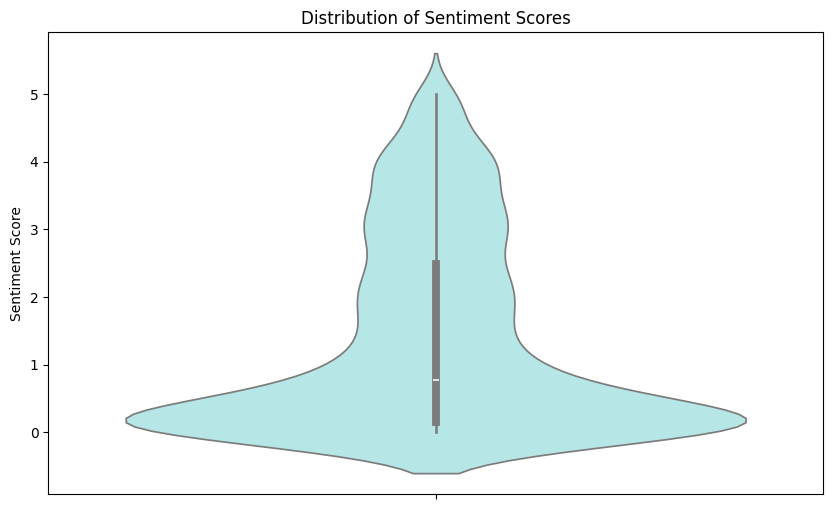

In [14]:
#Sentiment scores distribution
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    y="Senti_n", 
    color="paleturquoise",
)
plt.title("Distribution of Sentiment Scores")
plt.ylabel("Sentiment Score")
plt.show()


### Party status x Sentiment (categories, numerical scores)

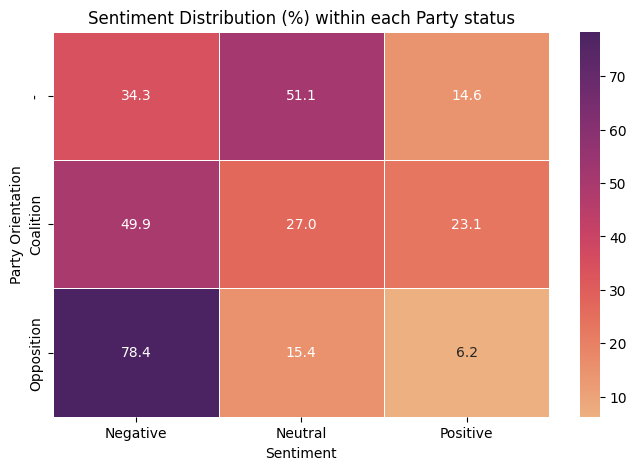

In [15]:
# Party status x Sentiment categories 
# Choose normalization mode: "row", "col", "global", or "none"

mode = "row"
senti_version = 3

if senti_version == 3:
    crosstab = pd.crosstab(df['Party_status'], df['Senti_3'])
elif senti_version == 6:
    crosstab = pd.crosstab(df['Party_status'], df['Senti_6'])
else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within each Party status"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Status Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Party Status"


plt.figure(figsize=(8, 5))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Party Orientation")
plt.xlabel("Sentiment")
plt.show()



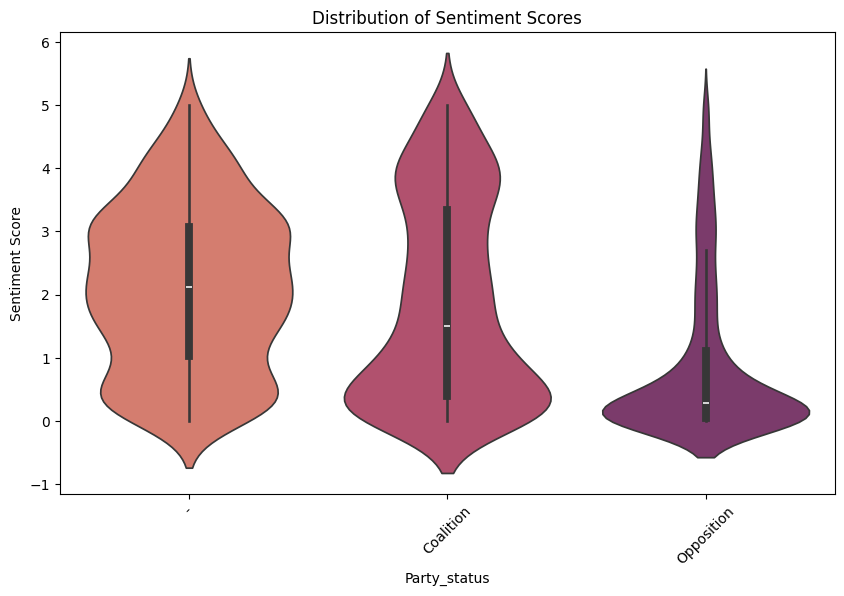

In [16]:
#Party status x sentiment score distribution

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Party_status",
    y="Senti_n", 
    hue="Party_status",
    palette="flare",
)
plt.title("Distribution of Sentiment Scores")
plt.ylabel("Sentiment Score")
plt.xlabel("Party_status")
plt.xticks(rotation=45)
plt.show()

In [17]:
#Party status x average sentiment score (across years)

status_term = df.groupby(["Party_status", "Month"]).agg({"Senti_n":"mean"}).reset_index()
status_term

fig=px.line(status_term, x="Month", y="Senti_n", color="Party_status", markers=True, 
            color_discrete_sequence=px.colors.qualitative.Vivid)
fig.update_layout(
    height=500,  
    width=950,
    yaxis=dict(range=[0, 5]),

    yaxis_title='Avg. Sentiment score',
    legend_title='Party',
    template='plotly_white'
)
fig.show()

### Political orientation x Sentiment (categories, scores)

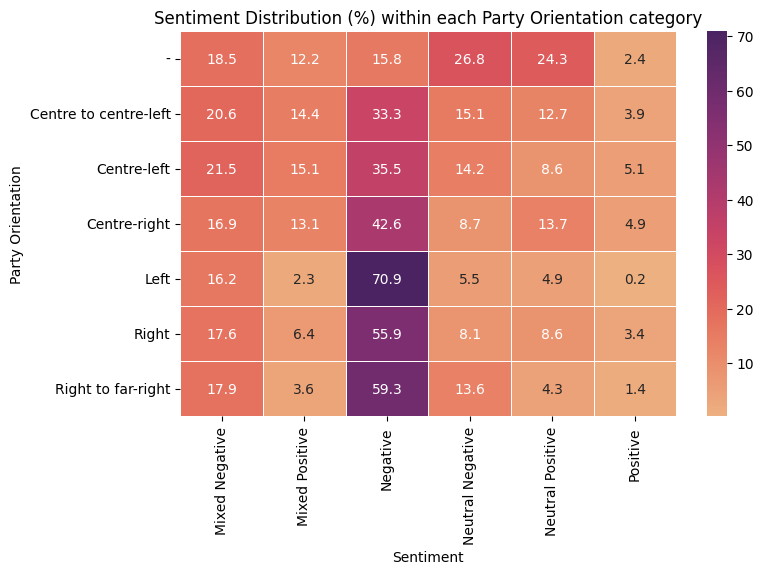

In [18]:
# Political orientation x Sentiment categories 
mode = "row"
senti_version = 6

if senti_version == 3:
    crosstab = pd.crosstab(df['Party_orientation'], df['Senti_3'])
elif senti_version == 6:
    crosstab = pd.crosstab(df['Party_orientation'], df['Senti_6'])
else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within each Party Orientation category"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Orientation Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Party Orientation"


plt.figure(figsize=(8, 5))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Party Orientation")
plt.xlabel("Sentiment")
plt.show()


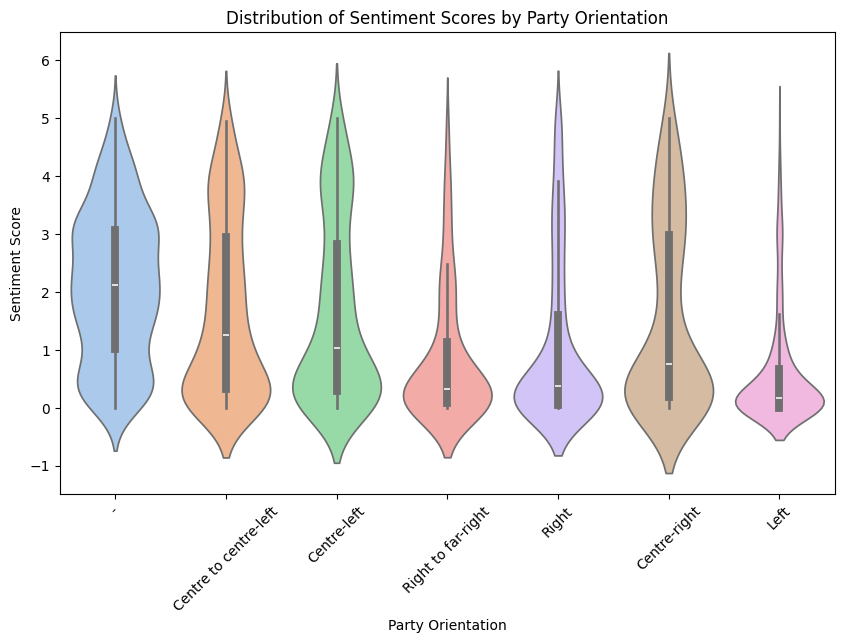

In [19]:
#Political orientation x sentiment scores (distributions)
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Party_orientation", 
    y="Senti_n", 
    hue="Party_orientation", 
    palette="pastel",
)
plt.title("Distribution of Sentiment Scores by Party Orientation")
plt.xlabel("Party Orientation")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=45)
plt.show()


In [20]:
#Political orientation x Sentiment scores (across years)

status_term = df.groupby(["Party_orientation", "Month"]).agg({"Senti_n":"mean"}).reset_index()
status_term

fig=px.line(status_term, x="Month", y="Senti_n", color="Party_orientation", markers=True, 
            color_discrete_sequence=px.colors.qualitative.Vivid)
fig.update_layout(
    height=500,  
    width=950,
    yaxis=dict(range=[0, 5]),

    yaxis_title='Avg. Sentiment score',
    legend_title='Orientation',
    template='plotly_white'
)
fig.show()

### Parliamentary groups/Political parties x Sentiment

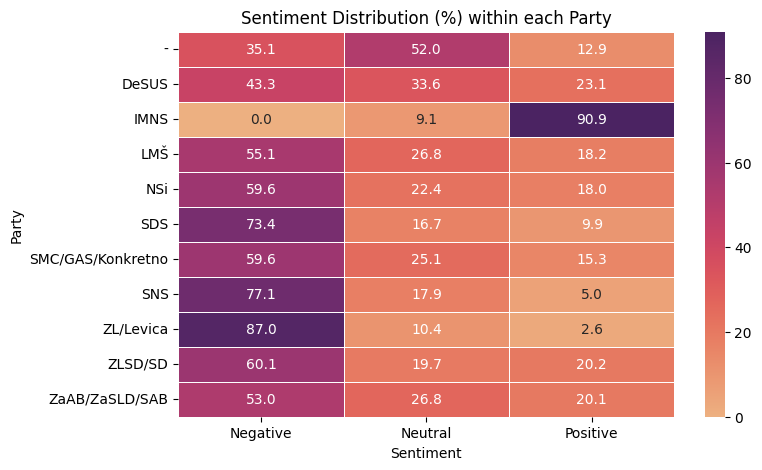

In [21]:
# Political party x Sentiment categories 
mode = "row"
senti_version = 3

if senti_version == 3:
    crosstab = pd.crosstab(df['Parties'], df['Senti_3'])
elif senti_version == 6:
    crosstab = pd.crosstab(df['Parties'], df['Senti_6'])
else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within each Party"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Party Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Party"


plt.figure(figsize=(8, 5))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Party")
plt.xlabel("Sentiment")
plt.show()


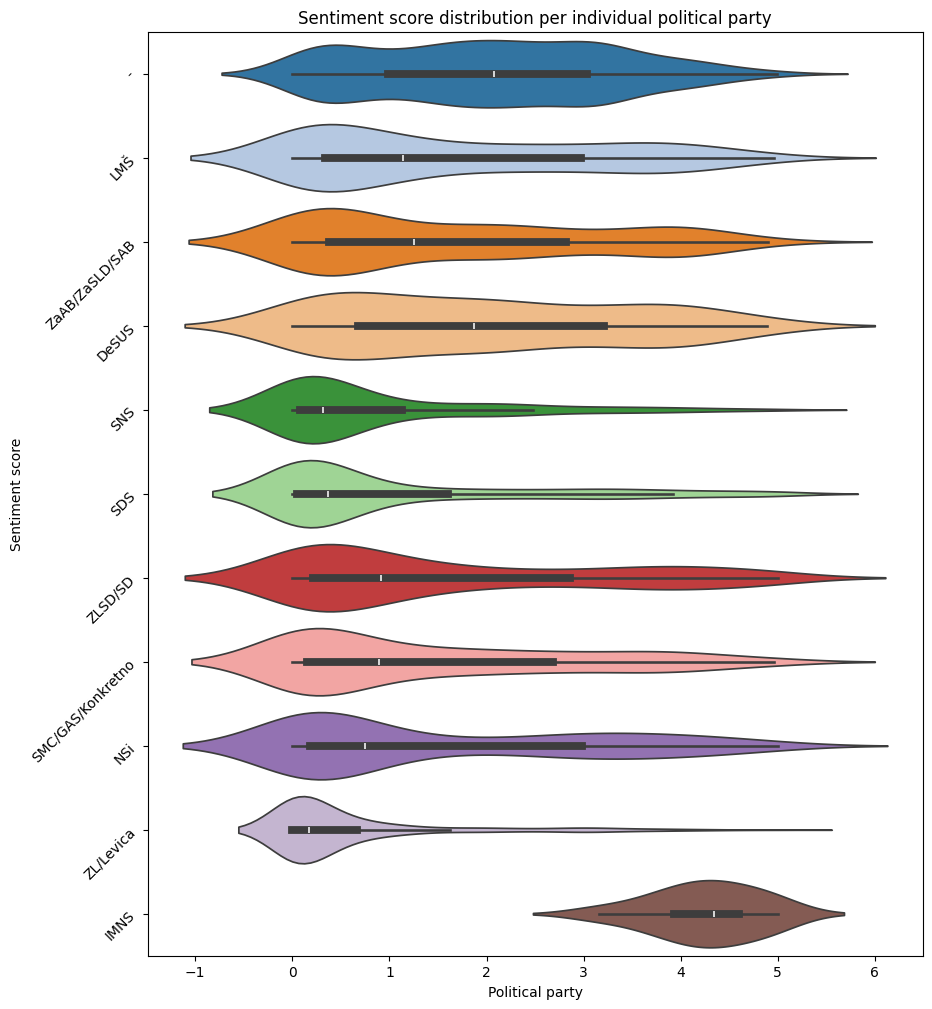

In [22]:
#Parliamentary groups x Sentiment score distributions
plt.figure(figsize=(10, 12))
sns.violinplot(
    data=df,
    x="Senti_n", 
    y="Parties",
    hue="Parties",
    palette="tab20"
)

plt.title("Sentiment score distribution per individual political party")
plt.xlabel("Political party"), 
plt.ylabel("Sentiment score"), 
plt.yticks(rotation=45), 
plt.show()

In [23]:
party_sent = df.groupby(["Term", "Year", "Parties"])["Senti_n"].mean().reset_index()
party_sent = party_sent.sort_values(by="Term")
party_sent["Senti_n"] = pd.to_numeric(party_sent["Senti_n"])
party_sent.head(10)


,Term,Year,Parties,Senti_n
0,Term 8,2019,-,2.034180
19,Term 8,2020,ZL/Levica,0.508745
18,Term 8,2020,SNS,0.990725
17,Term 8,2020,SMC/GAS/Konkretno,1.627714
16,Term 8,2020,SDS,1.649487
15,Term 8,2020,NSi,1.762644
14,Term 8,2020,LMŠ,1.376860
13,Term 8,2020,IMNS,4.220000
12,Term 8,2020,DeSUS,2.103115
11,Term 8,2020,-,2.086917


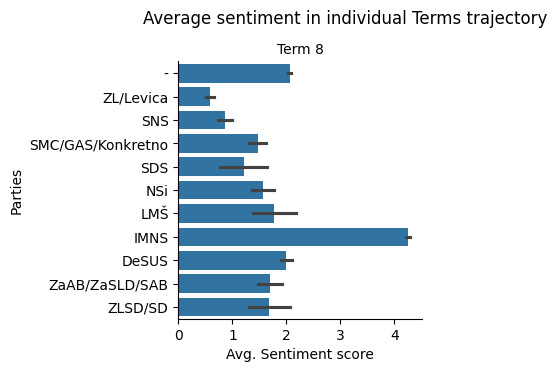

In [24]:
g = sns.FacetGrid(party_sent, col="Term" , col_wrap=2, height=3.5) 
g.map_dataframe(sns.barplot, x="Senti_n", y="Parties") 
g.set_axis_labels("Avg. Sentiment score", "Parties") 
g.set_titles("{col_name}"),
g.legend
g.figure.suptitle("Average sentiment in individual Terms trajectory", y=1.05)
plt.show()

## Families x Sentiment 

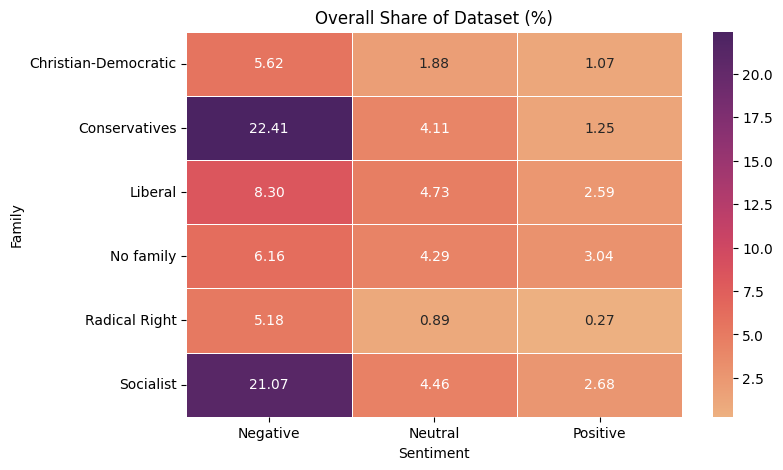

In [25]:
# Political party x Sentiment categories 
mode = "global"
senti_version = 3

if senti_version == 3:
    crosstab = pd.crosstab(df['Family'], df['Senti_3'])
elif senti_version == 6:
    crosstab = pd.crosstab(df['Family'], df['Senti_6'])
else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within each Family"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Family Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Family"


plt.figure(figsize=(8, 5))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Family")
plt.xlabel("Sentiment")
plt.show()

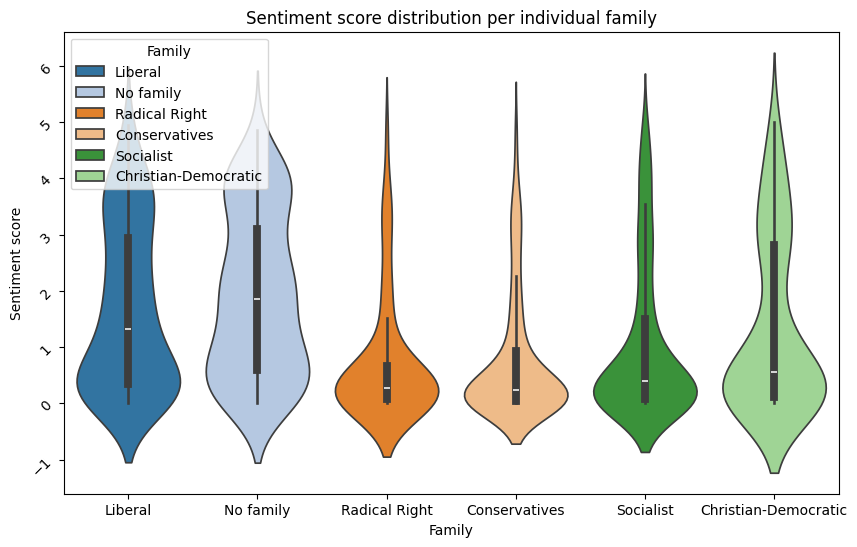

In [26]:
#Family x Sentiment score distributions
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Family", 
    y="Senti_n",
    hue="Family",
    palette="tab20"
)

plt.title("Sentiment score distribution per individual family")
plt.xlabel("Family"), 
plt.ylabel("Sentiment score"), 
plt.yticks(rotation=45), 
plt.show()

### Ministers distributions

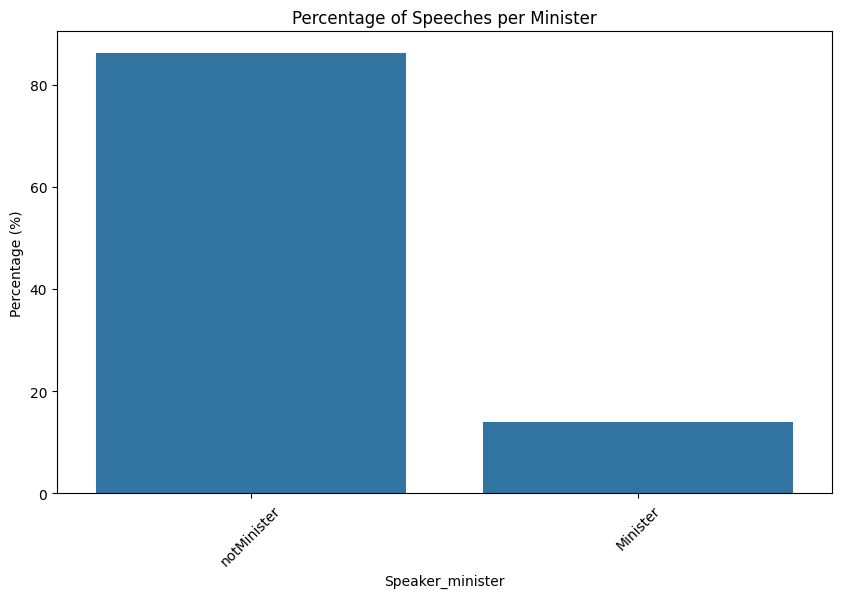

In [27]:
counts = df['Speaker_minister'].value_counts()
percentages = counts / counts.sum() * 100
plot_df = percentages.reset_index()
plot_df.columns = ['Speaker_minister', 'Percentage']

plt.figure(figsize=(10,6))
sns.barplot(data=plot_df, x='Speaker_minister', y='Percentage')
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.title("Percentage of Speeches per Minister")
plt.show()

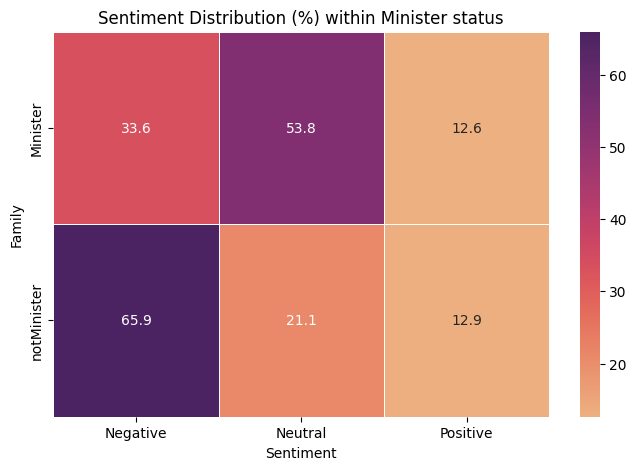

In [28]:
# Minister status x Sentiment categories 
mode = "row"
senti_version = 3

if senti_version == 3:
    crosstab = pd.crosstab(df['Speaker_minister'], df['Senti_3'])
elif senti_version == 6:
    crosstab = pd.crosstab(df['Speaker_minister'], df['Senti_6'])
else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within Minister status"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Minister status Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Minister status"


plt.figure(figsize=(8, 5))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Family")
plt.xlabel("Sentiment")
plt.show()

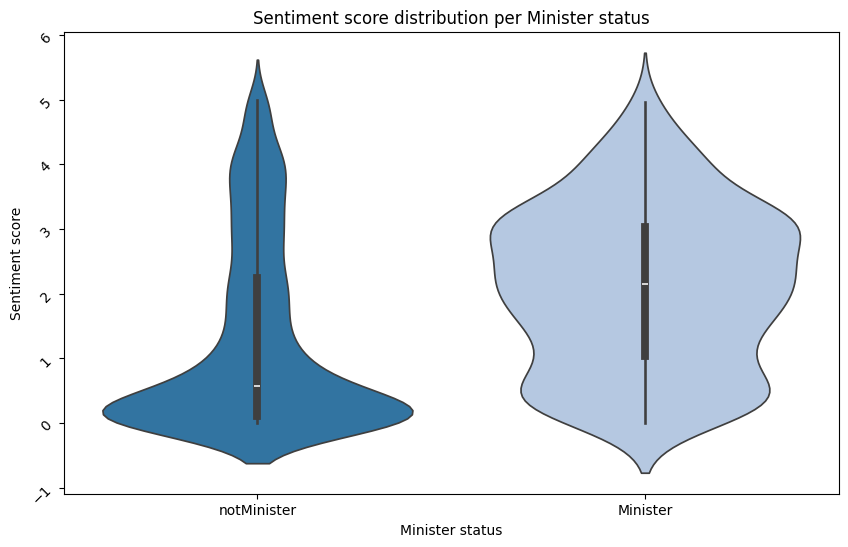

In [29]:
#Minister status x Sentiment score distributions
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Speaker_minister", 
    y="Senti_n",
    hue="Speaker_minister",
    palette="tab20"
)

plt.title("Sentiment score distribution per Minister status")
plt.xlabel("Minister status"), 
plt.ylabel("Sentiment score"), 
plt.yticks(rotation=45), 
plt.show()